In [6]:
import numpy as np
import pandas as pd 
import os

data_dir = "./SFS1/"

In [37]:
# load wav files from data_dir

audio_data = pd.DataFrame(columns=['filename', 'sampling_rate'])

wav_files = [f for f in os.listdir(data_dir) if f.endswith('.wav')]
for wav_file in wav_files:
    print(wav_file)
    # split the filename to get the sampling rate
    sampling_rate = wav_file.split('_')[4]
    # remove parantheses and what's inside them
    sampling_rate = sampling_rate.split('(')[0]
    sampling_rate = int(sampling_rate.split('.')[0])
    print(sampling_rate)
    audio_data.loc[len(audio_data)] = {'filename': wav_file, 'sampling_rate': sampling_rate}



sub2_block1_trial7_effector0_44.1 (8).wav
44
sub2_block1_trial6_effector0_8.wav
8
sub2_block1_trial4_effector0_16.wav
16
sub2_block1_trial4_effector0_16 (2).wav
16
sub2_block1_trial9_effector0_8.wav
8
sub2_block1_trial7_effector0_44.1 (4).wav
44
sub2_block1_trial7_effector0_44.1 (5).wav
44
sub2_block1_trial4_effector0_16 (3).wav
16
sub2_block1_trial1_effector0_8.wav
8
sub2_block1_trial4_effector0_16 (4).wav
16
sub2_block1_trial7_effector0_44.1 (2).wav
44
sub2_block1_trial4_effector0_16 (8).wav
16
sub2_block1_trial1_effector0_44.1.wav
44
sub2_block1_trial4_effector0_16 (9).wav
16
sub2_block1_trial7_effector0_8.wav
8
sub2_block1_trial8_effector0_8.wav
8
sub2_block1_trial7_effector0_44.1 (3).wav
44
sub2_block1_trial4_effector0_16 (5).wav
16
sub2_block1_trial4_effector0_16 (6).wav
16
sub2_block1_trial2_effector0_8.wav
8
sub2_block1_trial5_effector0_8.wav
8
sub2_block1_trial4_effector0_16 (7).wav
16
sub2_block1_trial7_effector0_44.1 (1).wav
44
sub2_block1_trial4_effector0_8.wav
8
sub2_block

In [44]:
f.shape

(513,)

44


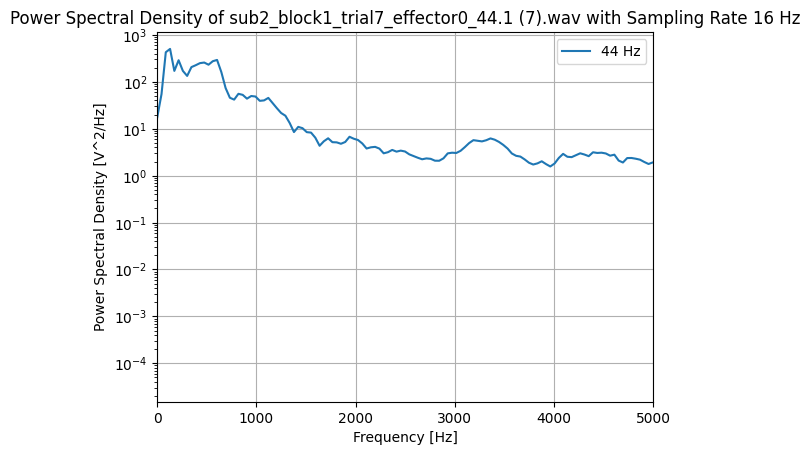

In [59]:
# for each sampling rate, generate a power spectral density plot of the audio files with that sampling rate
import matplotlib.pyplot as plt
from scipy.signal import welch
for sampling_rate in audio_data['sampling_rate'].unique():
    if sampling_rate < 20:
        continue
    print(sampling_rate)
    all_Pxxs = []
    # get the audio files with this sampling rate
    audio_files = audio_data[audio_data['sampling_rate'] == sampling_rate]['filename']
    for audio_file in audio_files:
        # load the audio file
        from scipy.io import wavfile
        sr, data = wavfile.read(os.path.join(data_dir, audio_file))
        # generate a power spectral density plot
        f, Pxx = welch(data, sr, nperseg=1024)
        all_Pxxs.append(Pxx)

    all_Pxxs = np.array(all_Pxxs)
    all_Pxxs_mean = np.mean(all_Pxxs, axis=0)
    plt.semilogy(f, all_Pxxs_mean, label=f'{sampling_rate} Hz')
plt.title(f'Power Spectral Density of {audio_file} with Sampling Rate {sampling_rate} Hz')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [V^2/Hz]')
plt.legend()
plt.xlim(0, 10000/2)
plt.grid()
